In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [31]:
model = ChatOpenAI(model_name="gpt-5-nano",    api_key=os.getenv("OPENAI_API_KEY"),
 temperature=0.7)

In [5]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog_post: str

In [9]:
def create_outline(state: BlogState) -> BlogState:
    topic = state["topic"]
    outline = model.invoke(f"Create an outline for a blog post about: {topic}")
    return {"topic": topic, "outline": outline, "blog_post": ""}

In [10]:
def create_blog(state: BlogState) -> BlogState:
    outline = state["outline"]
    blog_post = model.invoke(f"Write a blog post based on the following outline: {outline}")
    return {"topic": state["topic"], "outline": outline, "blog_post": blog_post}

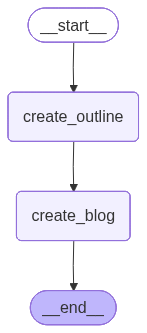

In [13]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)


workflow = graph.compile()



from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())


In [32]:
initial_state = {"topic": "The Future of Artificial Intelligence"}

result = workflow.invoke(initial_state)

In [33]:
print(result)

{'topic': 'The Future of Artificial Intelligence', 'outline': AIMessage(content='Here’s a detailed outline you can use for a blog post titled “The Future of Artificial Intelligence.”\n\n1) Title, Hook, and Overview\n- Compelling headline options\n- One-paragraph hook: why the future of AI matters now\n- Preview of what the reader will learn (what’s changing, why it matters, how to prepare)\n\n2) Section 1: The State of AI Today\n- Quick snapshot of current capabilities (models, autonomy, multimodal AI)\n- Notable breakthroughs and recent milestones\n- Current limitations and open problems\n- Why the future is being shaped by recent progress (data, compute, governance)\n\n3) Section 2: Key Drivers and Technologies Shaping the Future\n- Scaling laws, foundation models, and multimodal systems\n- Advances in reasoning, planning, memory, and safety research\n- AI at the edge vs. cloud\n- Interoperability, tools, and developer ecosystems\n- Emerging paradigms (e.g., AI-assisted design, hybri

{'topic': 'The Future of Artificial Intelligence', 'outline': AIMessage(content='Outline for a blog post: The Future of Artificial Intelligence\n\n1) Title and hook\n- Suggested title: The Future of Artificial Intelligence: What Comes Next and Why It Matters\n- Opening hook ideas: a brief near-future scenario, a provocative question, or a bold forecast to frame the discussion\n\n2) Introduction\n- Define AI in today’s context (narrow vs. general AI, foundation models, automation)\n- Why the future of AI matters: potential productivity, societal change, ethical and governance questions\n- What readers will gain from the post (overview of trends, impacts, and calls to action)\n\n3) Where we stand today (short recap)\n- Current capabilities and limitations of AI systems\n- Notable deployments across industries\n- Key bottlenecks: data, compute, alignment, safety, and trust\n\n4) Driving forces shaping the future\n- Advances in machine learning architectures and data availability\n- Rise of foundation models and AI as a platform\n- Edge computing and real-time inference\n- Multimodal, multilingual, and autonomous AI capabilities\n- AI safety, robustness, and interpretability research\n- Shifts in hardware, energy efficiency, and cost dynamics\n\n5) Possible future scenarios (three to four concise visions)\n- Optimistic/transformational: widespread productivity gains, new industries, high-quality AI assistive tools for all\n- Moderate/balanced: productivity uplift with managed disruption, retraining programs, gradual adoption\n- Cautious/regulated: strong governance, slower deployment due to safety concerns and compliance\n- Cautionary/critical (optional): risks of inequality, misinformation, and concentration of power; need for safeguards\n- For each scenario: drivers, likely timelines, and what changes readers might notice\n\n6) Economic and labor implications\n- Productivity vs. job displacement: where humans gain complementary roles\n- New job categories and required skills (AI literacy, data fluency, systems thinking)\n- Industry-by-industry impacts (healthcare, finance, manufacturing, education, creative industries)\n- How organizations can manage transitions (upskilling, reskilling, onboarding AI responsibly)\n\n7) Societal, ethical, and governance considerations\n- Privacy, bias, fairness, and transparency\n- Accountability, liability, and redress mechanisms\n- AI safety and alignment with human values\n- Regulation, standards, and governance models (national vs. global coordination)\n- Equity and global disparities in AI access and benefit\n\n8) Risks and challenges to address\n- Data quality, security, and adversarial threats\n- Black-box decision making and explainability\n- Misuse (deepfakes, automation of cyberattacks, harmful automation)\n- Concentration of power among a few tech entities or nations\n- Misinformation, trust, and social cohesion\n\n9) Roadmap: near-term, mid-term, and long-term milestones\n- Near-term (0-5 years): improvements in assistive AI, deployment in defined sectors, safety frameworks\n- Mid-term (5-15 years): more autonomous systems, more capable agents, regulatory maturation\n- Long-term (15+ years): potential generalized capabilities, profound societal shifts, new governance paradigms\n- Key indicators to watch (adoption rates, safety incidents, regulatory changes)\n\n10) Practical guidance for readers\n- For individuals: skills to develop, ethical considerations, ways to engage with AI tools responsibly\n- For organizations: responsible adoption, governance, safety and risk assessment, transparency with stakeholders\n- For policymakers: evidence-based regulation, safety standards, incentives for innovation with safeguards\n\n11) Case studies and real-world examples (2–4 brief vignettes)\n- Healthcare: AI-assisted diagnostics and personalized treatment planning\n- Manufacturing: predictive maintenance and autonomous logistics\n- Education: personalized learning at scale\n- Creative industries: AI-assisted content creation and design\n- Lessons learned from early adopters and missteps to avoid\n\n12) Conclusion\n- Recap of the key takeaways\n- A forward-looking, balanced stance: embrace benefits while actively managing risks\n- Final thought or call to action (comment, share, follow for updates)\n\nOptional add-ons (if you want to tailor the post):\n- Audience-focused versions: one for general readers, one for technology professionals, and one for policymakers\n- Sidebar ideas: glossary of AI terms, a timeline of notable milestones, a quick FAQ\n- Visuals suggestions: a timeline graphic, a before/after scenario comparison, and a simple risk matrix\n\nIf you’d like, I can tailor this outline to a specific audience (general readers, industry professionals, or policymakers) or a particular word count.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1909, 'prompt_tokens': 20, 'total_tokens': 1929, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 960, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DwePd5S8cRIO1AxYmocJiHCxDsq4i', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f1b60-8dbd-72b0-a909-a4c35cb01506-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 1909, 'total_tokens': 1929, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 960}}), 'blog_post': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3000, 'prompt_tokens': 1259, 'total_tokens': 4259, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 3000, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DwePpVjSWBQ3rnI802CybyGMgIvLs', 'service_tier': 'default', 'finish_reason': 'length', 'logprobs': None}, id='lc_run--019f1b60-c12d-7e60-a8da-d96dedcb7434-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1259, 'output_tokens': 3000, 'total_tokens': 4259, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 3000}})}

In [34]:
print(result["blog_post"])

content="The Future of Artificial Intelligence: Opportunities, Risks, and How to Prepare\n\nHeadline options you can use\n- The Future of Artificial Intelligence: Opportunities, Risks, and How to Prepare\n- Beyond the Hype: The Real Trajectory of AI’s Next Decade\n- AI Tomorrow: How Machines Learn, Decide, and Shape Our World\n- From Algorithms to Autonomy: The AI Frontier in Our Lifetime\n\nHook: Why the future of AI matters now\nArtificial intelligence isn’t a distant sci-fi concept—it's already weaving through how we work, learn, heal, and govern. The next decade promises breakthroughs that could unlock unprecedented productivity, tackle stubborn societal challenges, and reshape entire industries. But with great capability comes great responsibility: safety, fairness, privacy, and governance will decide whether AI amplifies opportunity or amplifies risk. The future is being written today by researchers, policymakers, businesses, and everyday users who choose how to design, deploy, a